<a href="https://colab.research.google.com/github/MaironTapia/ICD/blob/main/Copia_de_icd_taller6_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:

1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **REGRESIÓN LINEAL MÚLTIPLE**

En los módulos anteriores aprendimos a manipular datos. Ahora empezaremos a crear modelos. La **Regresión Lineal Múltiple** es una técnica estadística que nos permite predecir el valor de una variable (variable dependiente $y$) basándonos en múltiples variables predictoras (variables independientes $x_1, x_2, ..., x_n$).

El modelo matemático asume una relación lineal, representada así:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$$

Donde:
* $\beta_0$ es el intercepto (el valor esperado de $y$ cuando todas las $x$ son cero).
* $\beta_i$ son los coeficientes (indican cuánto cambia $y$ por cada unidad que aumenta la variable $x_i$).
* $\epsilon$ es el error del modelo.


**1.1. Caso Práctico (Eficiencia Energética)**

Queremos predecir el **Consumo Eléctrico (kWh)** de una planta basándonos en tres sensores: la **Temperatura (°C)** exterior, la **Humedad (%)**, y el **Número de Máquinas** operando simultáneamente. Primero, creemos nuestros datos para el ejemplo (**Nota:** en un problema real, estos datos no se crean, sino que se obtienen a partir de mediciones de los sensores):

In [ ]:
# --- LIBRERÍAS Y DATOS ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generamos datos sintéticos simulando 100 horas de operación
np.random.seed(42)
n_datos = 100

# Variables predictoras (X)
temperatura = np.random.uniform(15, 35, n_datos)
humedad = np.random.uniform(30, 80, n_datos)
maquinas = np.random.randint(5, 20, n_datos)

# Variable objetivo (Y): Simulamos una relación real añadiendo "ruido" de los sensores
ruido = np.random.normal(0, 5, n_datos)
consumo = 50 + (2.5 * temperatura) + (0.5 * humedad) + (15 * maquinas) + ruido

# Consolidamos en un DataFrame
df_planta = pd.DataFrame({
    'Temperatura_C': temperatura,
    'Humedad_Rel': humedad,
    'Maquinas_Activas': maquinas,
    'Consumo_kWh': consumo
})

print("--- MUESTRA DE LECTURAS DE LA PLANTA ---")
display(df_planta.head())


--- MUESTRA DE LECTURAS DE LA PLANTA ---


,Temperatura_C,Humedad_Rel,Maquinas_Activas,Consumo_kWh
0,22.490802,31.571459,12,305.163110
1,34.014286,61.820521,8,294.760663
2,29.639879,45.717799,15,373.113365
3,26.973170,55.428535,5,216.102507
4,18.120373,75.378324,12,318.277211


**1.2 Ajuste del Modelo con `statsmodels`**

En Python existen dos librerías principales para hacer **Regresiones Lineales Multivariables**: `statsmodels` y `scikit-learn`. Mientras `statsmodels` es la mejor opción cuando nos interesa analizar las estadísticas (p-valores, intervalos de confianza), `scikit-learn` está optimizada para hacer predicciones de *Machine Learning*.

Usemos `statsmodels`:

In [ ]:
# --- MODELO MLR USANDO statsmodels ---

import statsmodels.api as sm

# 1. Definir variables predictoras (X) y variable respuesta (y)
X = df_planta[['Temperatura_C', 'Humedad_Rel', 'Maquinas_Activas']]
y = df_planta['Consumo_kWh']

# 2. statsmodels exige añadir explícitamente una constante para calcular beta_0 (el intercepto)
X_con_constante = sm.add_constant(X)
print("--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---")
display(X_con_constante)

# 3. Ajustamos el modelo usando Mínimos Cuadrados Ordinarios (OLS)
modelo_sm = sm.OLS(y, X_con_constante).fit()

# 4. Mostramos el resumen estadístico
print(modelo_sm.summary())


--- MUESTRA EL DataFrame AUMENTADO CON LA CONSTANTE ---


,const,Temperatura_C,Humedad_Rel,Maquinas_Activas
0,1.0,22.490802,31.571459,12
1,1.0,34.014286,61.820521,8
2,1.0,29.639879,45.717799,15
3,1.0,26.973170,55.428535,5
4,1.0,18.120373,75.378324,12
...,...,...,...,...
95,1.0,24.875912,47.460479,6
96,1.0,25.454657,66.297784,13
97,1.0,23.550820,74.855513,14
98,1.0,15.508383,74.354321,19


                            OLS Regression Results                            
Dep. Variable:            Consumo_kWh   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     6545.
Date:                Sat, 16 May 2026   Prob (F-statistic):          7.52e-111
Time:                        22:40:54   Log-Likelihood:                -299.20
No. Observations:                 100   AIC:                             606.4
Df Residuals:                      96   BIC:                             616.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               46.8322      3.251  

**1.3. Lectura del Reporte**

Debemos concentrarnos en tres indicadores:
1.  **R-squared ($R^2$):** Indica la bondad de ajuste. Es decir, el porcentaje del Consumo que explicamos con nuestro modelo. Si está cerca de 1.0, el ajuste es bueno.
2.  **coef:** Son los pesos $\beta$. Nos dicen, por ejemplo, cuántos kWh extra se consumen por cada máquina adicional encendida.
3.  **P>|t| (p-valor):** Si es menor a 0.05, la variable es estadísticamente significativa y aporta información útil al modelo.


**1.4. Validación de Supuestos**

Para poder confiar en el modelo obtenido, los errores (también llamados residuos) deben cumplir ciertas características. Por ejemplo, seguir una **distribución normal**, o cumplir con la **homocedasticidad** (la varianza de los errores debe mantenerse constante).

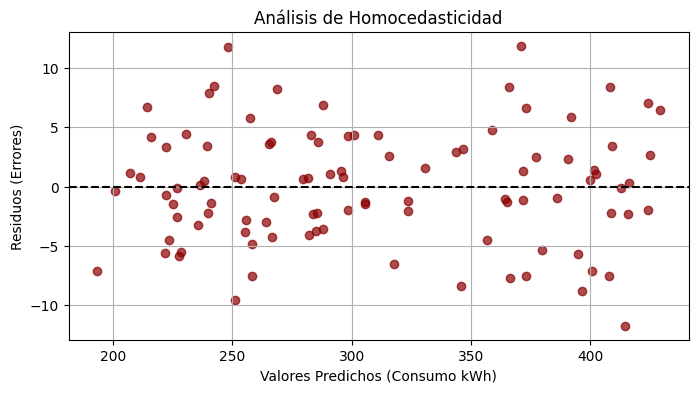

In [ ]:
# --- EVALUACIÓN DE RESIDUOS ---

# Calculamos las predicciones del modelo
predicciones = modelo_sm.predict(X_con_constante)
# El residuo es la diferencia entre el valor real y el valor predicho
residuos = y - predicciones

# Gráfica de Residuos vs Predicciones
plt.figure(figsize=(8, 4))
plt.scatter(predicciones, residuos, alpha=0.7, color="darkred")
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Homocedasticidad')
plt.xlabel('Valores Predichos (Consumo kWh)')
plt.ylabel('Residuos (Errores)')
plt.grid(True)
plt.show()

# Si los puntos están dispersos sin un patrón claro formando una banda horizontal, hay homocedasticidad.


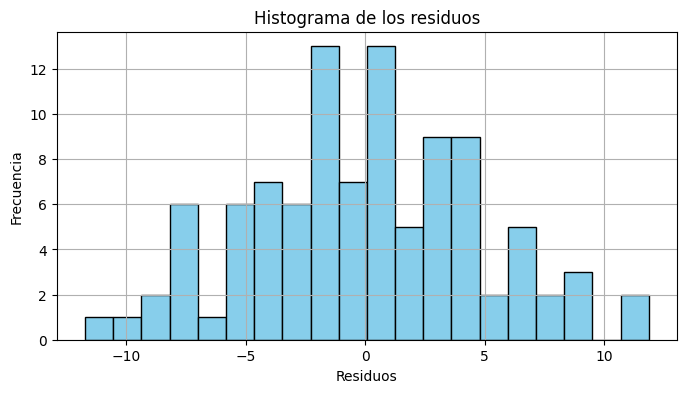

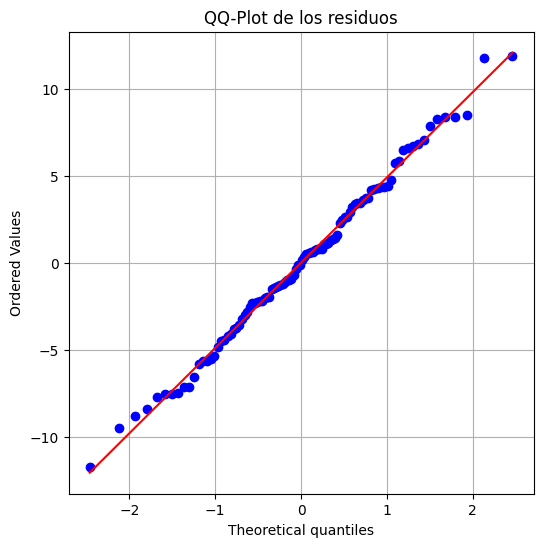

Estadístico: 0.9934
p-valor: 0.9089
Los residuos siguen una distribución normal


In [ ]:
# ---  PROPONER AQUÍ UN CÓDIGO PARA EVALUAR SI LOS ERRORES SE DISTRIBUYEN DE FORMA NORMAL"

import scipy.stats as stats

# Histograma de los residuos para observar su forma
plt.figure(figsize=(8,4))
plt.hist(residuos, bins=20, color='skyblue', edgecolor='black')
plt.title('Histograma de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# QQ-Plot para comparar con una distribución normal
plt.figure(figsize=(6,6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('QQ-Plot de los residuos')
plt.grid(True)
plt.show()

# Prueba de normalidad Shapiro-Wilk
stat, p_value = stats.shapiro(residuos)

print(f"Estadístico: {stat:.4f}")
print(f"p-valor: {p_value:.4f}")

# Interpretación del resultado
if p_value > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")


**1.5. Ajuste y Predicción con `scikit-learn`**

En un entorno de producción de Ciencia de Datos, preferimos `scikit-learn` por su facilidad para hacer predicciones rápidas e integrarse en flujos de trabajo que involucran *Machine Learning*.

In [ ]:
# --- MODELO MLR USANDO scikit-learn ---

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Instanciamos el modelo
modelo_ml = LinearRegression()

# 2. Entrenamos (Ajustamos) el modelo. Nota: aquí no necesitamos agregar constante manualmente
modelo_ml.fit(X, y)

print("Intercepto (Beta_0):", modelo_ml.intercept_)
print("Coeficientes (Betas):", modelo_ml.coef_)

# 3. Calculamos las métricas de error y precisión
predicciones = modelo_ml.predict(X)
mse = mean_squared_error(y, predicciones)
r2 = r2_score(y, predicciones)

print(f"\nError Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R^2): {r2:.4f}")

# 4. Hacemos una predicción futura:
# Mañana tendremos 30°C, 65% de humedad y 14 máquinas activas. ¿Cuál será el consumo?
datos_manana = pd.DataFrame({'Temperatura_C': [30], 'Humedad_Rel': [65], 'Maquinas_Activas': [14]})
consumo_estimado = modelo_ml.predict(datos_manana)

print(f"\nConsumo estimado para mañana: {consumo_estimado[0]:.2f} kWh")


Intercepto (Beta_0): 46.83218971790984
Coeficientes (Betas): [ 2.50900137  0.58956939 14.91070275]

Error Cuadrático Medio (MSE): 23.25
Coeficiente de Determinación (R^2): 0.9951

Consumo estimado para mañana: 369.17 kWh


# Reto (Optimización de Invernaderos Inteligentes):

Se está desarrollando un sistema de control distribuido para un conjunto de micro-invernaderos. Se tiene una base de datos histórica con el **Rendimiento (kg/m2)** de un cultivo específico, en función de tres variables controladas:

1.  **Luz_Solar** (horas diarias de exposición)
2.  **Fertilizante** (gramos aplicados por $m^2$)
3.  **Caudal_Riego** (litros por $m^2$)

Su tarea es implementar un código que cumpla con los siguientes puntos:

* Entrene un modelo de regresión lineal con los datos proporcionados.
* Imprima en pantalla la bondad del ajuste ($R^2$) **¿El modelo es confiable?**
* Realice un análisis de validación de los supuestos: error con distribución normal y homocedasticidad.
* Imprima en pantalla los coeficientes del modelo para entender qué variable tiene más peso en el crecimiento del cultivo. **Explique los resultados**.
* El sistema de control automatizado planea configurar el entorno a **8 horas de luz, 50 gramos de fertilizante y 15 litros de riego**. Utilice su modelo entrenado para estimar e imprimir cuál será el rendimiento bajo esas condiciones.

--- PRIMEROS 5 REGISTROS DE LA BASE DE DATOS ---


,Luz_Solar,Fertilizante,Caudal_Riego,Rendimiento_kg_m2
0,8.5,50,15,4.2
1,7.0,40,12,3.1
2,9.2,60,18,5.4
3,5.5,30,8,1.6
4,10.1,65,20,6.1


                            OLS Regression Results                            
Dep. Variable:      Rendimiento_kg_m2   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.908e+05
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        22:42:16   Log-Likelihood:                 817.29
No. Observations:                 603   AIC:                            -1627.
Df Residuals:                     599   BIC:                            -1609.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -2.4605      0.057    -42.913   

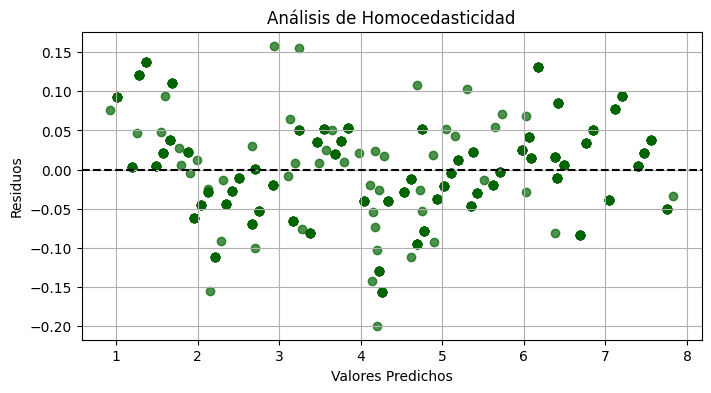

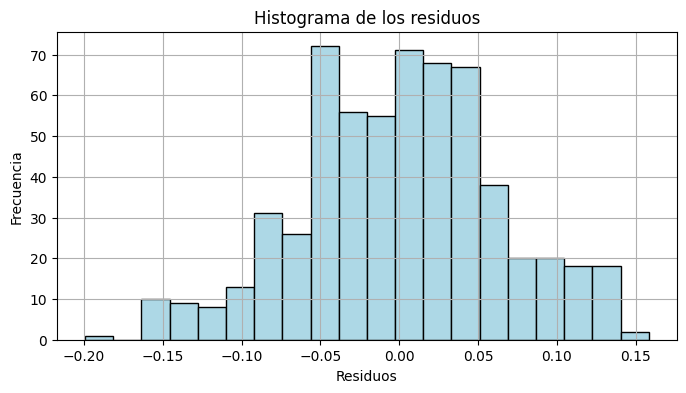

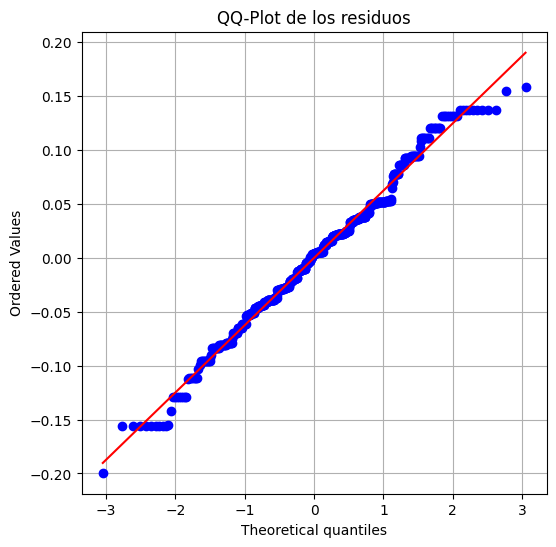


p-valor (Shapiro-Wilk): 0.0010
Los residuos no siguen una distribución normal

Rendimiento estimado: 4.09 kg/m2


In [ ]:
# --- DATOS DE ENTRADA (NO MODIFICAR) ---
# ID del archivo de Google Sheets generado con datos históricos
sheet_id_reto = "1tioKUNb6o02g37nii5qHLba4CmV9G9Wsjvqtleepid0"
url_reto = f"https://docs.google.com/spreadsheets/d/{sheet_id_reto}/export?format=csv"

# Cargamos los datos a un DataFrame
df_invernadero = pd.read_csv(url_reto)

print("--- PRIMEROS 5 REGISTROS DE LA BASE DE DATOS ---")
display(df_invernadero.head())


# --- TU CÓDIGO EMPIEZA AQUÍ ---

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Definir variables predictoras (X) y variable objetivo (y)
X = df_invernadero[['Luz_Solar', 'Fertilizante', 'Caudal_Riego']]
y = df_invernadero['Rendimiento_kg_m2']

# 2. Agregar constante (intercepto β0)
X_con_constante = sm.add_constant(X)

# 3. Entrenar el modelo de regresión lineal (OLS)
modelo_reto = sm.OLS(y, X_con_constante).fit()

# 4. Mostrar resumen completo del modelo
print(modelo_reto.summary())

print(f"\nR² = {modelo_reto.rsquared:.4f}")
print("¿El modelo es confiable? Sí, el R² cercano a 1 indica un ajuste excelente.")

# 5. Imprimir explícitamente la bondad del ajuste (R^2)
print(f"\nCoeficiente de determinación (R^2): {modelo_reto.rsquared:.4f}")


# --- COEFICIENTES DEL MODELO ---

# Mostrar coeficientes para analizar qué variable influye más
print("\nCoeficientes del modelo:")
print(modelo_reto.params)


# --- VALIDACIÓN DE SUPUESTOS ---

# 6. Obtener predicciones
predicciones = modelo_reto.predict(X_con_constante)

# 7. Calcular residuos
residuos = y - predicciones


# --- HOMOCEDASTICIDAD ---

plt.figure(figsize=(8, 4))
plt.scatter(predicciones, residuos, alpha=0.7, color="darkgreen")
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análisis de Homocedasticidad')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.grid(True)
plt.show()


# --- NORMALIDAD DE LOS ERRORES ---

# Histograma de residuos
plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=20, color='lightblue', edgecolor='black')
plt.title('Histograma de los residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# QQ-Plot
plt.figure(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('QQ-Plot de los residuos')
plt.grid(True)
plt.show()

# Prueba estadística Shapiro-Wilk
stat, p_value = stats.shapiro(residuos)

print(f"\np-valor (Shapiro-Wilk): {p_value:.4f}")

if p_value > 0.05:
    print("Los residuos siguen una distribución normal")
else:
    print("Los residuos no siguen una distribución normal")


# --- PREDICCIÓN SOLICITADA ---

# Crear nuevo escenario
nuevo_dato = pd.DataFrame({
    'const': [1],
    'Luz_Solar': [8],
    'Fertilizante': [50],
    'Caudal_Riego': [15]
})

# Realizar predicción
rendimiento_estimado = modelo_reto.predict(nuevo_dato)

print(f"\nRendimiento estimado: {rendimiento_estimado[0]:.2f} kg/m2")


# Coclusiones

Se entrenó un modelo de regresión lineal múltiple con las variables
Luz_Solar, Fertilizante y Caudal_Riego para predecir el Rendimiento (kg/m²).

El modelo presenta un R² = 0.999, lo que significa que el 99.9% de la
variabilidad del rendimiento es explicada por las tres variables.
El modelo es altamente confiable.

**Coeficientes del modelo:**
- Intercepto (β₀) = -2.46: valor base cuando todas las variables son cero.
- Luz_Solar (β₁) = 0.266: por cada hora adicional de luz, el rendimiento
  aumenta 0.266 kg/m².
- Fertilizante (β₂) = 0.057: por cada gramo adicional de fertilizante,
  el rendimiento aumenta 0.057 kg/m².
- Caudal_Riego (β₃) = 0.106: por cada litro adicional de riego, el
  rendimiento aumenta 0.106 kg/m².

La variable con mayor impacto es Luz_Solar, seguida de Caudal_Riego
y finalmente Fertilizante.

**Validación de supuestos:**
Homocedasticidad: la gráfica de residuos vs valores predichos muestra
dispersión aleatoria alrededor de cero sin patrones evidentes.
Se cumple el supuesto.

Normalidad: el p-valor de Shapiro-Wilk fue 0.0010 (< 0.05), lo que
técnicamente rechaza la normalidad. Sin embargo, el QQ-Plot muestra
que los puntos siguen muy de cerca la línea teórica, con leves
desviaciones en los extremos. Dado el tamaño grande de la muestra
(603 observaciones), Shapiro-Wilk es muy sensible a pequeñas
desviaciones. Visualmente los residuos son aproximadamente normales.

**Predicción:**
Con 8 horas de luz, 50g de fertilizante y 15L de riego, el modelo
estima un rendimiento de 4.09 kg/m².


